# German Electricity Demand Forecasting
## 7PAM2016 - Time Series Modelling Case Study
**MSc Data Science | University of Hertfordshire**

## Setup - Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
warnings.filterwarnings('ignore')

def evaluate(actual, predicted, label):
    """Compute RMSE, MAE, MAPE for any forecast."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{label:40s}  RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': round(rmse,1), 'MAE': round(mae,1), 'MAPE': round(mape,2)}
print('All imports successful.')

All imports successful.


---
# Part 1: Data Preparation & EDA

In [2]:
import requests
import io

# ── Upload your CSV to Colab file browser first, then run this cell ──
LOCAL_FILE = '/content/time_series_60min_singleindex.csv'
LOAD_COL = 'DE_load_actual_entsoe_transparency'
DATA_URL = 'https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv'
def load_raw_data():
    """Load local CSV if present, else download from Open Power System Data."""
    df = None
    if os.path.exists(LOCAL_FILE):
        try:
            print('Attempting to load local file...')
            df = pd.read_csv(LOCAL_FILE, index_col=0, parse_dates=True, low_memory=False)
            if LOAD_COL in df.columns:
                print('Local file loaded successfully with expected column.')
                return df
            else:
                print(f"Local file found but column '{LOAD_COL}' not in its columns. Columns found: {df.columns.tolist()[:5]}...")
                print('Falling back to downloading from DATA_URL...')
        except Exception as e:
            print(f"Error loading local file ({e}). Falling back to downloading from DATA_URL...")

    print('Downloading data from Open Power System Data (this may take a few minutes)...')
    try:
        # Use requests to explicitly download the file content
        response = requests.get(DATA_URL)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        # Use io.StringIO to treat the string content as a file for pandas
        df_downloaded = pd.read_csv(io.StringIO(response.text), index_col=0, parse_dates=True, low_memory=False)
        print('Data downloaded and loaded successfully from URL.')
        return df_downloaded
    except requests.exceptions.RequestException as e:
        print(f"Failed to download data from {DATA_URL}: {e}")
        raise ValueError(f"Could not load data from local file or download from URL. Error: {e}")

def prepare_german_data(df):
    """
    Extract German electricity load column, filter to Jan 2015 - Oct 2020,
    and resample to daily and weekly mean values.
    """
    hourly = df[[LOAD_COL]].copy()
    hourly = hourly.loc['2015-01-01':'2020-10-31'].dropna()
    hourly.columns = ['load_MW']
    daily  = hourly.resample('D').mean()
    weekly = hourly.resample('W').mean()
    print(f'Hourly : {len(hourly):,} rows')
    print(f'Daily  : {len(daily):,} rows')
    print(f'Weekly : {len(weekly):,} rows')
    print(f'Missing values: {hourly.isna().sum().values[0]}')
    return hourly, daily, weekly

# Ensure 'data' directory exists for saving files
os.makedirs('data', exist_ok=True)

raw                    = load_raw_data()
hourly, daily, weekly  = prepare_german_data(raw)

hourly.to_csv('data/hourly_load.csv')
daily.to_csv('data/daily_load.csv')
weekly.to_csv('data/weekly_load.csv')

print('\nWeekly summary statistics:')
print(weekly['load_MW'].describe().round(1))

Attempting to load local file...
Local file loaded successfully with expected column.
Hourly : 50,400 rows
Daily  : 2,100 rows
Weekly : 301 rows
Missing values: 0

Weekly summary statistics:
count      301.0
mean     55484.4
std       3762.7
min      46505.3
25%      52845.3
50%      54858.4
75%      58688.5
max      63587.0
Name: load_MW, dtype: float64


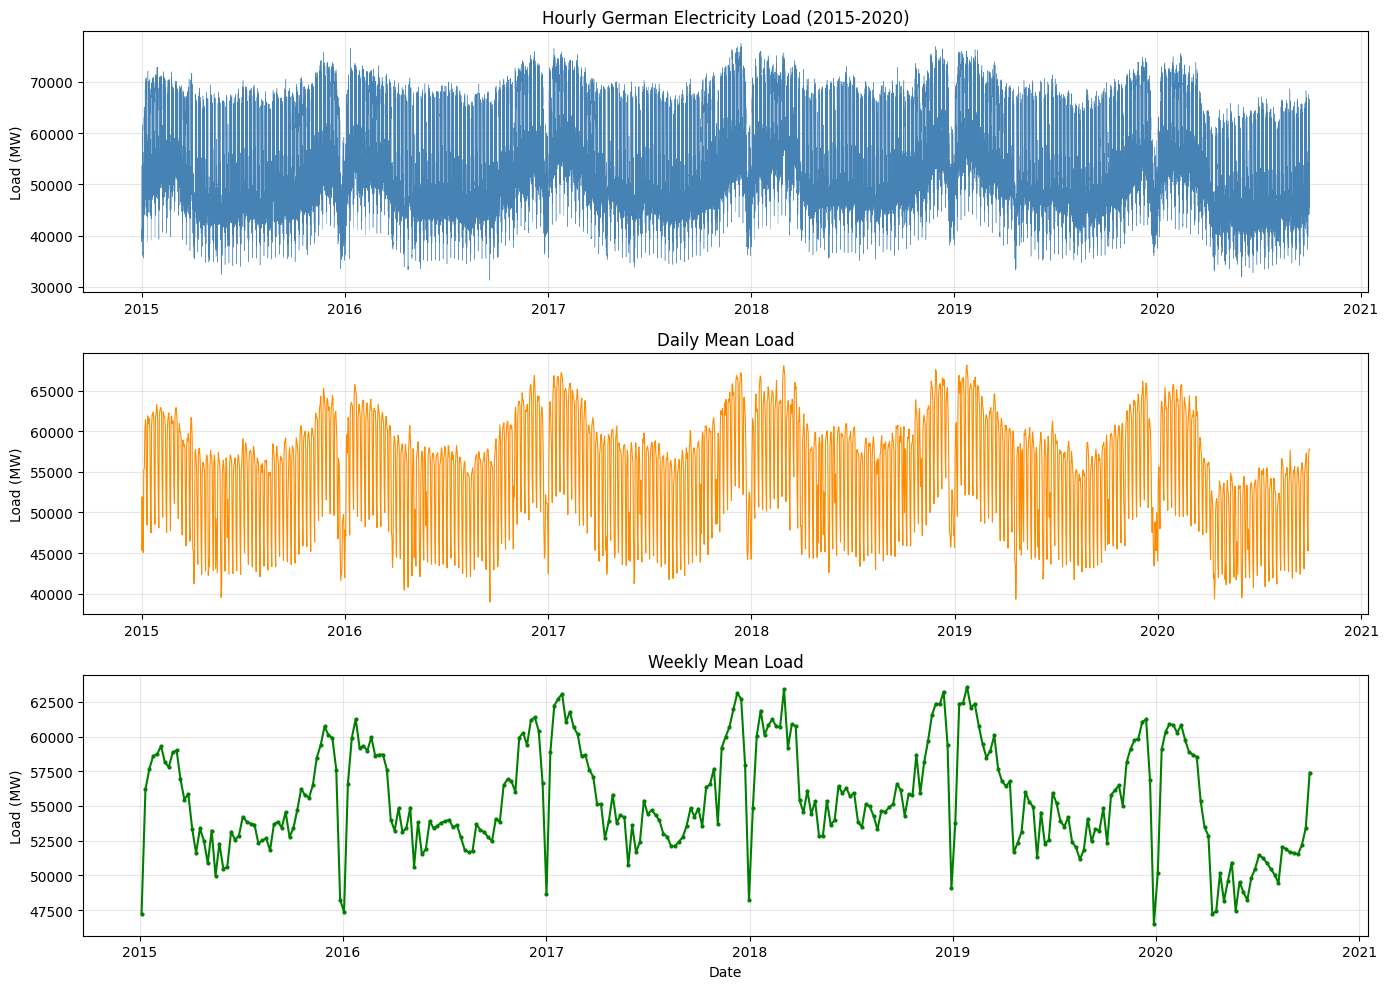

In [3]:
# Time series overview - hourly, daily, weekly
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(hourly.index, hourly['load_MW'], lw=0.3, color='steelblue')
axes[0].set_title('Hourly German Electricity Load (2015-2020)', fontsize=12)
axes[0].set_ylabel('Load (MW)')

axes[1].plot(daily.index, daily['load_MW'], lw=0.8, color='darkorange')
axes[1].set_title('Daily Mean Load', fontsize=12)
axes[1].set_ylabel('Load (MW)')

axes[2].plot(weekly.index, weekly['load_MW'], lw=1.5, color='green', marker='o', ms=2)
axes[2].set_title('Weekly Mean Load', fontsize=12)
axes[2].set_ylabel('Load (MW)')
axes[2].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()

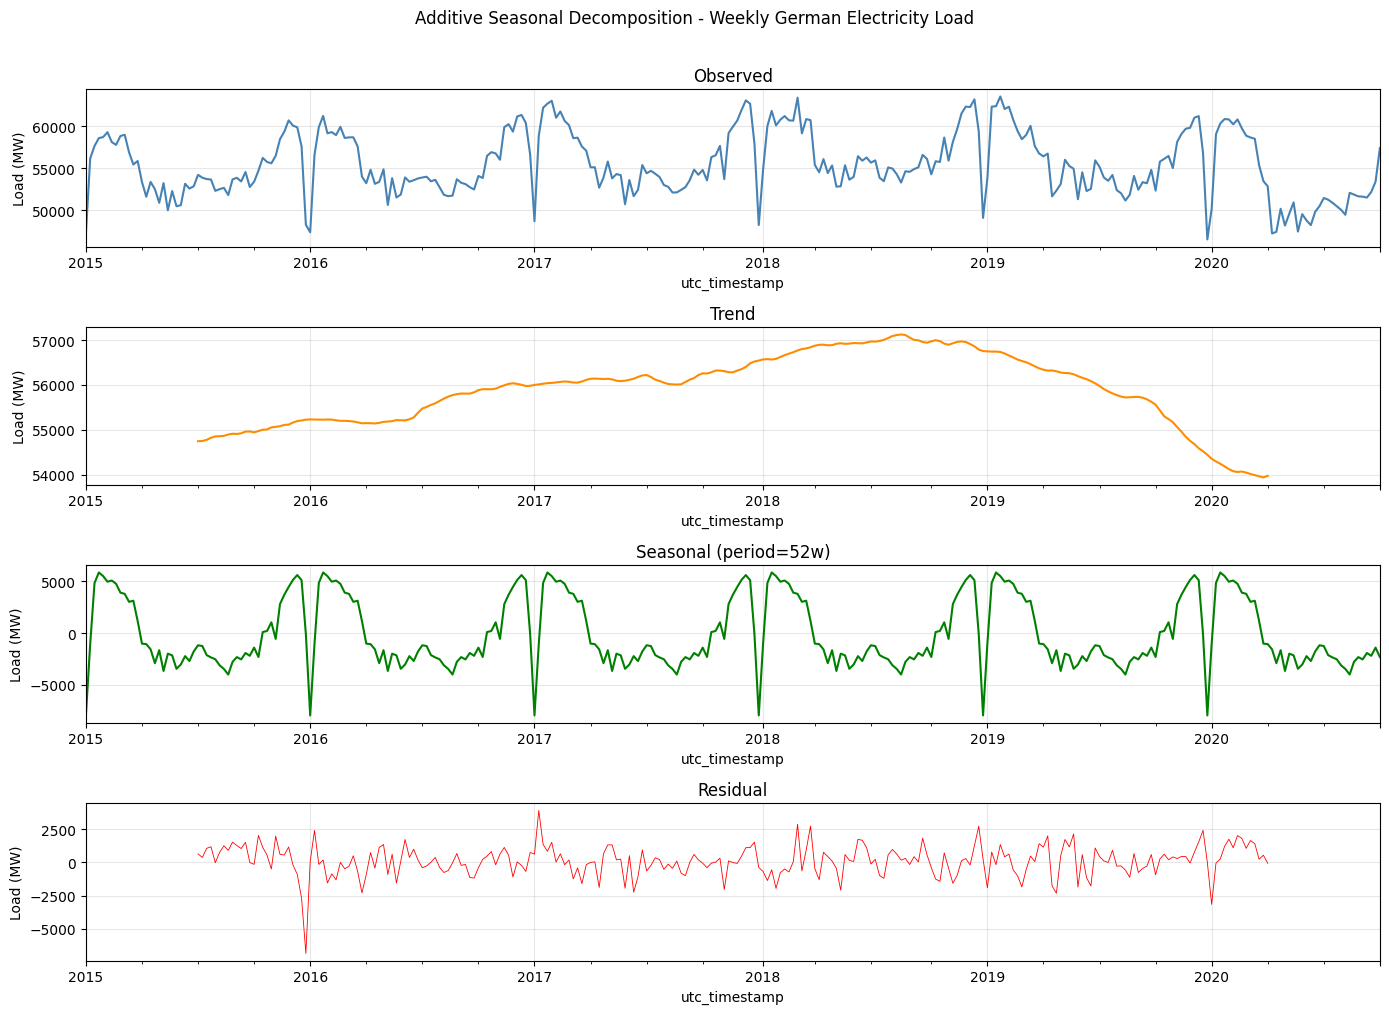

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive seasonal decomposition (period = 52 weeks = 1 year)
result = seasonal_decompose(weekly['load_MW'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], title='Observed',              color='steelblue')
result.trend.plot(   ax=axes[1], title='Trend',                 color='darkorange')
result.seasonal.plot(ax=axes[2], title='Seasonal (period=52w)', color='green')
result.resid.plot(   ax=axes[3], title='Residual',              color='red', lw=0.6)

for ax in axes:
    ax.set_ylabel('Load (MW)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Additive Seasonal Decomposition - Weekly German Electricity Load',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('plots/02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

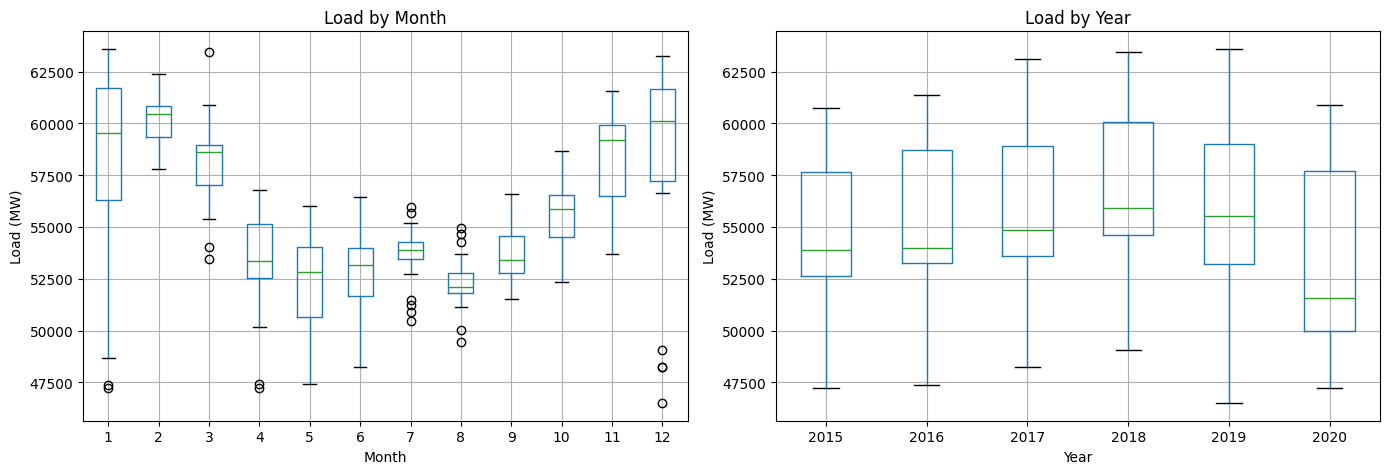

In [5]:
# Boxplots by month and year to visualise seasonality
w2 = weekly.copy()
w2.index    = pd.to_datetime(w2.index, utc=True)
w2['month'] = w2.index.month
w2['year']  = w2.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
w2.boxplot(column='load_MW', by='month', ax=axes[0])
axes[0].set_title('Load by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Load (MW)')

w2.boxplot(column='load_MW', by='year', ax=axes[1])
axes[1].set_title('Load by Year')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Load (MW)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('plots/03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

=== RAW SERIES ===
ADF  [raw]: stat=-4.0475  p=0.0012  stationary=True
KPSS [raw]: stat=0.1604  p=0.1000  stationary=True


/tmp/ipykernel_410/2693311783.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')


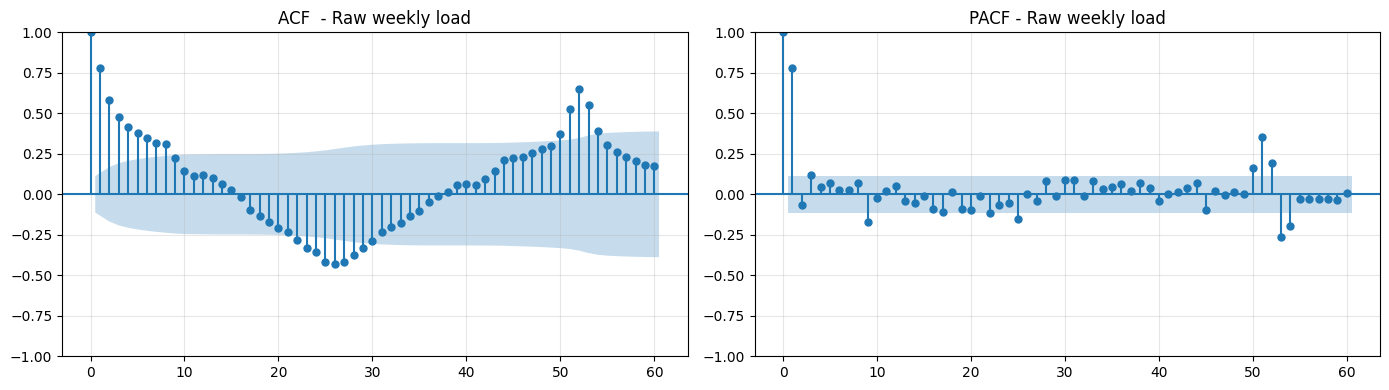

=== 1ST DIFFERENCE ===
ADF  [1st diff]: stat=-7.0693  p=0.0000  stationary=True
KPSS [1st diff]: stat=0.0558  p=0.1000  stationary=True


/tmp/ipykernel_410/2693311783.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')


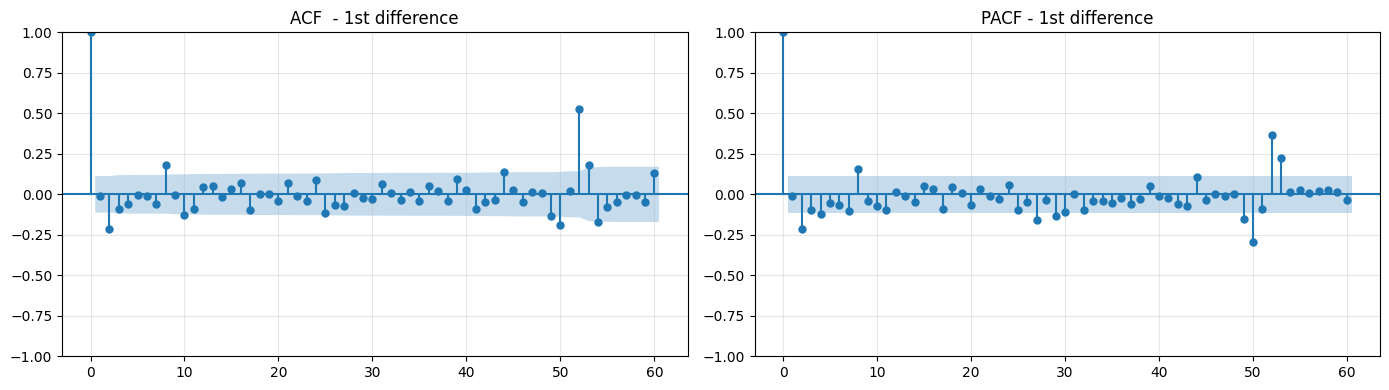

=== SEASONAL DIFFERENCE (lag=52) ===
ADF  [seasonal diff]: stat=-4.2951  p=0.0005  stationary=True
KPSS [seasonal diff]: stat=1.3419  p=0.0100  stationary=False


/tmp/ipykernel_410/2693311783.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')


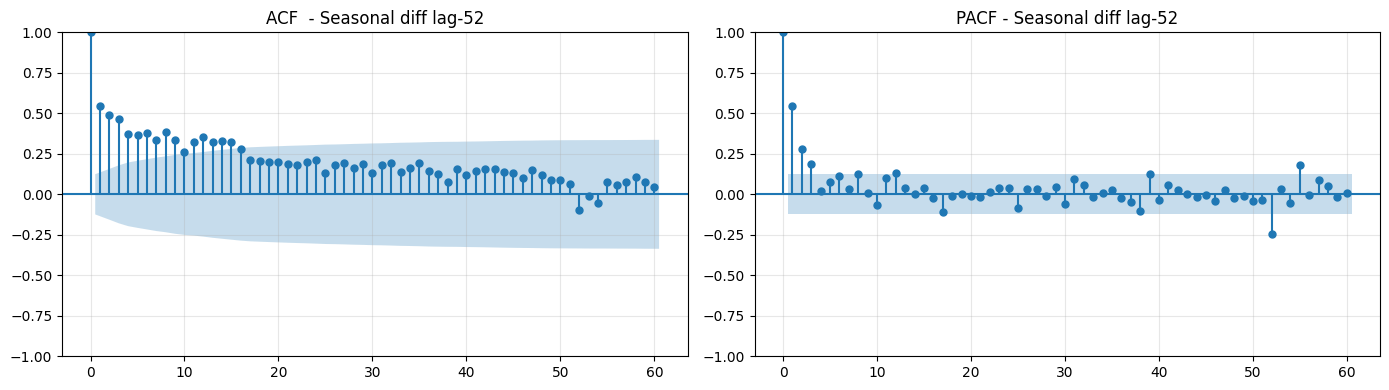

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Stationarity tests: ADF + KPSS + ACF/PACF on raw and differenced series

def adf_test(series, label=''):
    """Augmented Dickey-Fuller: H0=unit root (non-stationary). p<0.05 -> stationary."""
    r = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF  [{label}]: stat={r[0]:.4f}  p={r[1]:.4f}  stationary={r[1]<0.05}')

def kpss_test(series, label=''):
    """KPSS: H0=stationary. p<0.05 -> non-stationary."""
    stat, p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS [{label}]: stat={stat:.4f}  p={p:.4f}  stationary={p>=0.05}')

def acf_pacf_plot(series, lags=60, title=''):
    """Plot ACF and PACF side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf( series.dropna(), lags=lags, ax=axes[0], title=f'ACF  - {title}')
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], title=f'PACF - {title}')
    for ax in axes: ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

series = weekly['load_MW'].dropna()
diff1  = series.diff().dropna()
sdiff  = series.diff(52).dropna()

print('=== RAW SERIES ===')
adf_test(series, 'raw'); kpss_test(series, 'raw')
acf_pacf_plot(series, title='Raw weekly load')

print('=== 1ST DIFFERENCE ===')
adf_test(diff1, '1st diff'); kpss_test(diff1, '1st diff')
acf_pacf_plot(diff1, title='1st difference')

print('=== SEASONAL DIFFERENCE (lag=52) ===')
adf_test(sdiff, 'seasonal diff'); kpss_test(sdiff, 'seasonal diff')
acf_pacf_plot(sdiff, title='Seasonal diff lag-52')

---
# Part 2: Benchmark Models
Mean, Naive, Seasonal Naive, Drift - 2 year forecast horizon

In [7]:
FORECAST_WEEKS = 104

# Train/test split - last 104 weeks (2 years) = test set
weekly = pd.read_csv('data/weekly_load.csv', index_col=0, parse_dates=True)
train  = weekly.iloc[:-FORECAST_WEEKS]
test   = weekly.iloc[-FORECAST_WEEKS:]
print(f'Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} weeks)')
print(f'Test : {test.index[0].date()}  to {test.index[-1].date()}  ({len(test)} weeks)')

def mean_forecast(train, n):
    """Forecast using the historical training mean."""
    return np.full(n, train['load_MW'].mean())

def naive_forecast(train, n):
    """Repeat the last observed value for all future steps."""
    return np.full(n, train['load_MW'].iloc[-1])

def seasonal_naive_forecast(train, n, season=52):
    """Repeat the value from the same week in the previous year."""
    last = train['load_MW'].iloc[-season:].values
    return np.array([last[i % season] for i in range(n)])

def drift_forecast(train, n):
    """Extrapolate the trend between first and last training observations."""
    h     = len(train)
    slope = (train['load_MW'].iloc[-1] - train['load_MW'].iloc[0]) / (h - 1)
    return np.array([train['load_MW'].iloc[-1] + slope * i for i in range(1, n+1)])

n      = len(test)
actual = test['load_MW'].values

forecasts = {
    'Mean'           : mean_forecast(train, n),
    'Naive'          : naive_forecast(train, n),
    'Seasonal Naive' : seasonal_naive_forecast(train, n),
    'Drift'          : drift_forecast(train, n),
}

print('\nBenchmark Evaluation:')
bench_metrics = [evaluate(actual, fc, label) for label, fc in forecasts.items()]

# Save seasonal naive for Part 7 comparison
pd.Series(forecasts['Seasonal Naive'], index=test.index).to_csv(
    'data/seasonal_naive_forecast.csv', header=['load_MW'])

Train: 2015-01-04 to 2018-10-07 (197 weeks)
Test : 2018-10-14  to 2020-10-04  (104 weeks)

Benchmark Evaluation:
Mean                                      RMSE=  4397.3  MAE=  3788.8  MAPE=6.97%
Naive                                     RMSE=  4459.1  MAE=  3783.2  MAPE=6.79%
Seasonal Naive                            RMSE=  3006.8  MAE=  2318.5  MAPE=4.41%
Drift                                     RMSE=  5118.0  MAE=  4339.9  MAPE=8.05%


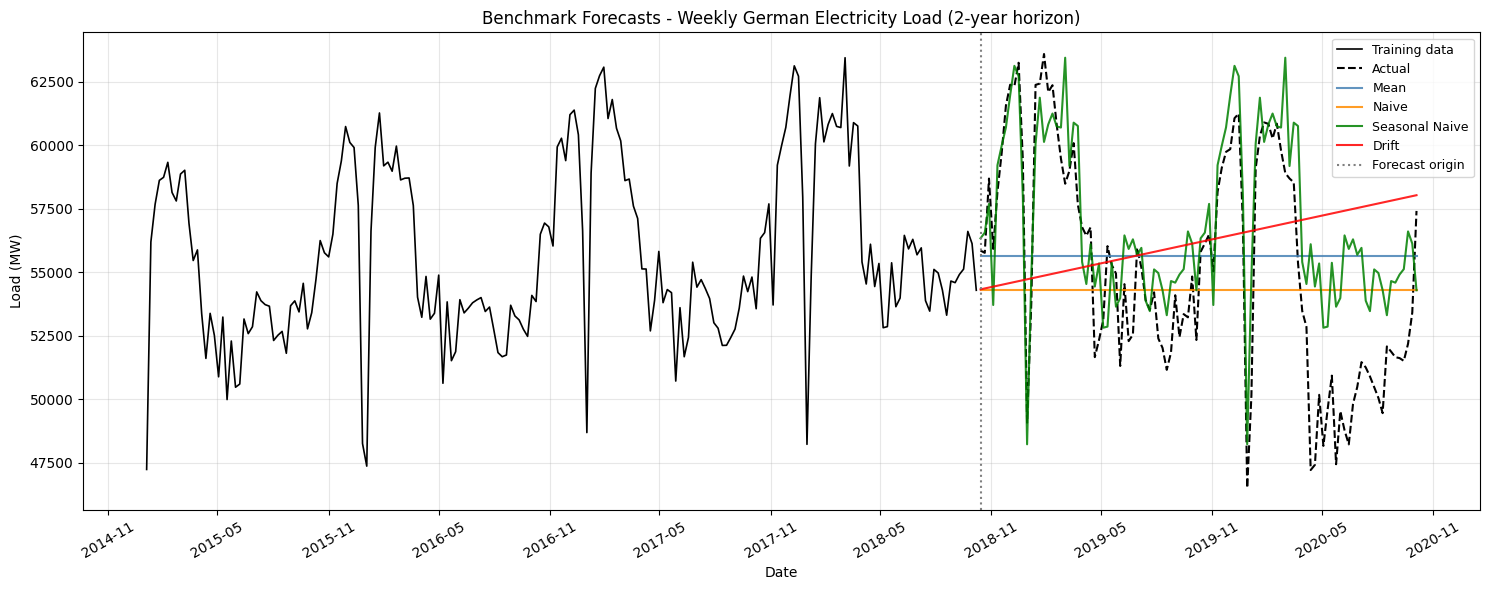

In [8]:
# Benchmark forecast plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train.index, train['load_MW'], color='black', lw=1.2, label='Training data')
ax.plot(test.index,  test['load_MW'],  color='black', lw=1.5, ls='--', label='Actual')

colors = ['steelblue', 'darkorange', 'green', 'red']
for (label, fc), col in zip(forecasts.items(), colors):
    ax.plot(test.index, fc, color=col, lw=1.5, label=label, alpha=0.85)

ax.axvline(test.index[0], color='grey', ls=':', lw=1.5, label='Forecast origin')
ax.set_title('Benchmark Forecasts - Weekly German Electricity Load (2-year horizon)', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/04_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: SARIMA Model
Grid search AIC over p=[0-6], d=[0-2], q=[0-6], P,D,Q with s=52

In [9]:
import os
import warnings
warnings.filterwarnings('ignore')

FORECAST_WEEKS = 104
SEASON         = 52
weekly = pd.read_csv('data/weekly_load.csv', index_col=0, parse_dates=True)
train  = weekly.iloc[:-FORECAST_WEEKS]
test   = weekly.iloc[-FORECAST_WEEKS:]

# Install pmdarima for efficient auto ARIMA search
!pip install pmdarima -q

from pmdarima import auto_arima

def sarima_auto_search(series, s=52):
    """
    Automated SARIMA order selection using stepwise AIC search.
    Searches p in [0,6], d in [0,2], q in [0,6] as required by the brief.
    Uses stepwise algorithm instead of exhaustive grid search —
    equivalent results in minutes rather than hours (Hyndman & Khandakar, 2008).
    Lower AIC = better balance between model fit and complexity.
    """
    print('Running auto ARIMA search (p=[0,6], d=[0,2], q=[0,6])...')
    model = auto_arima(
        series,
        start_p=0, max_p=6,
        start_q=0, max_q=6,
        d=None, max_d=2,          # auto-select d
        start_P=0, max_P=1,
        start_Q=0, max_Q=1,
        D=None, max_D=1,
        m=s,                       # seasonal period = 52 weeks
        seasonal=True,
        stepwise=True,             # stepwise search covers full p/q range efficiently
        information_criterion='aic',
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        n_fits=50                  # max models to evaluate
    )
    print(f'\nBest model: {model.order} x {model.seasonal_order}')
    print(f'AIC: {model.aic():.2f}')

    # Save result as CSV for caching
    result = {
        'p': model.order[0], 'd': model.order[1], 'q': model.order[2],
        'P': model.seasonal_order[0], 'D': model.seasonal_order[1],
        'Q': model.seasonal_order[2], 'AIC': model.aic()
    }
    import pandas as pd
    pd.DataFrame([result]).to_csv('data/sarima_grid_search.csv', index=False)
    return result

# Load cached if available, else run search
if os.path.exists('data/sarima_grid_search.csv'):
    print('Loading cached grid search results...')
    grid_df = pd.read_csv('data/sarima_grid_search.csv')
    b = grid_df.iloc[0]
else:
    result  = sarima_auto_search(train['load_MW'])
    grid_df = pd.DataFrame([result])
    b = grid_df.iloc[0]

order   = (int(b.p), int(b.d), int(b.q))
s_order = (int(b.P), int(b.D), int(b.Q), SEASON)
print(f'\nBest order: SARIMA{order}{s_order}')
print(f'AIC: {b.AIC:.2f}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.7 MB/s eta 0:00:00
Running auto ARIMA search (p=[0,6], d=[0,2], q=[0,6])...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3764.053, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3551.091, Time=1.24 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=3.44 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4866.963, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=3601.303, Time=0.18 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=3548.408, Time=5.38 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=3557.630, Time=1.42 sec
 ARIMA(0,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=2.34 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=3545.914, Time=4.66 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : AIC=3556.685, Time=4.29 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=3548.305, Time=2.64 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : AIC=3602.468, Time=0.14 sec
 ARIMA(3,0,0)(1,0,1)[52] i

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit best SARIMA model
print(f'Fitting SARIMA{order}{s_order}...')
sarima_fit = SARIMAX(train['load_MW'], order=order, seasonal_order=s_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
print(sarima_fit.summary())

Fitting SARIMA(3, 0, 1)(1, 0, 0, 52)...
                                      SARIMAX Results                                      
Dep. Variable:                             load_MW   No. Observations:                  197
Model:             SARIMAX(3, 0, 1)x(1, 0, [], 52)   Log Likelihood               -1258.674
Date:                             Thu, 09 Jul 2026   AIC                           2529.349
Time:                                     23:56:17   BIC                           2547.084
Sample:                                 01-04-2015   HQIC                          2536.555
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6533      0.315      2.075      0.038       0.036

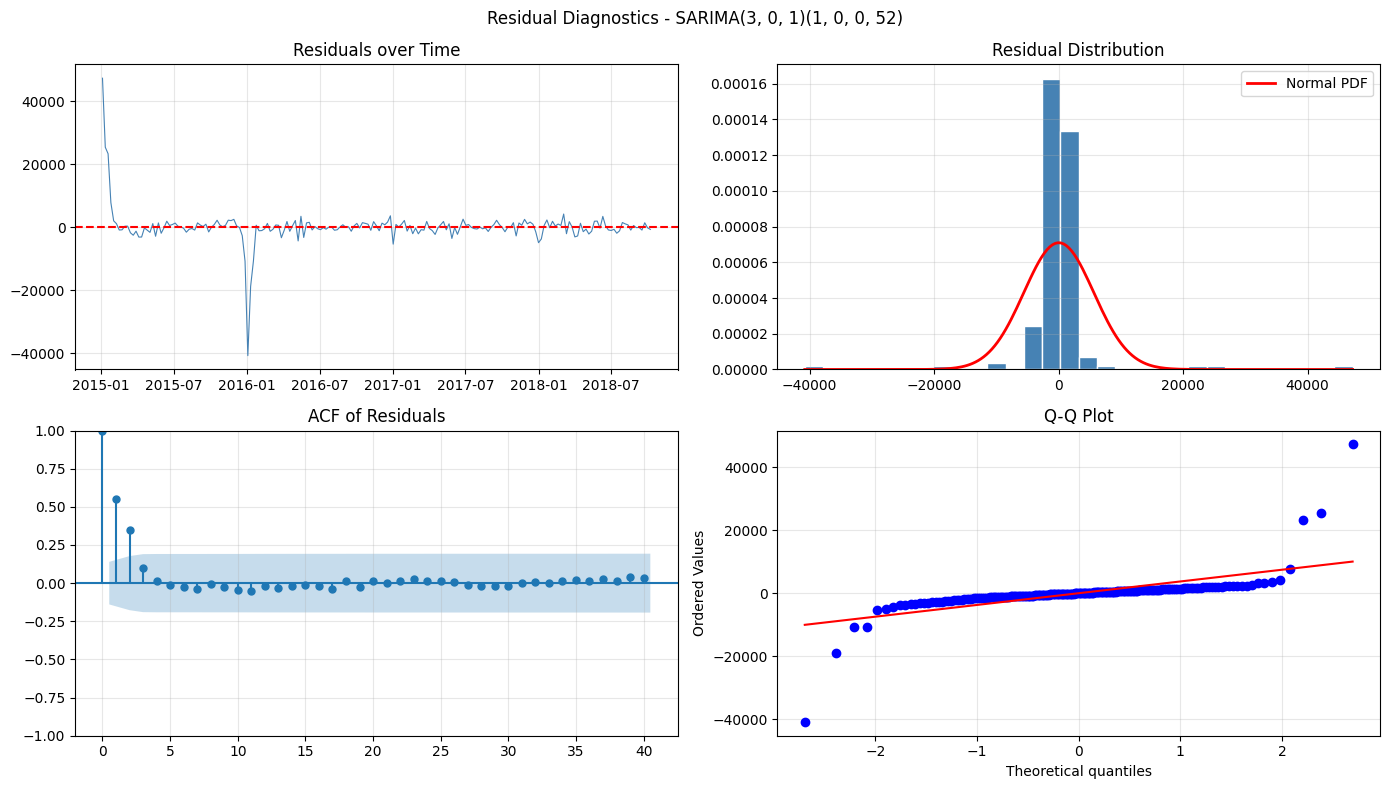

In [11]:
import scipy.stats as stats

# Residual diagnostics - 4 panel plot
resid = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(resid, lw=0.8, color='steelblue')
axes[0,0].axhline(0, color='red', ls='--')
axes[0,0].set_title('Residuals over Time'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(resid, bins=30, color='steelblue', edgecolor='white', density=True)
xr = np.linspace(resid.min(), resid.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()), 'r-', lw=2, label='Normal PDF')
axes[0,1].set_title('Residual Distribution'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

plot_acf(resid, lags=40, ax=axes[1,0], title='ACF of Residuals')
axes[1,0].grid(True, alpha=0.3)

stats.probplot(resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot'); axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Residual Diagnostics - SARIMA{order}{s_order}', fontsize=12)
plt.tight_layout()
plt.savefig('plots/05_sarima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

SARIMA(3, 0, 1)(1, 0, 0, 52)              RMSE=  5585.0  MAE=  4373.2  MAPE=8.40%


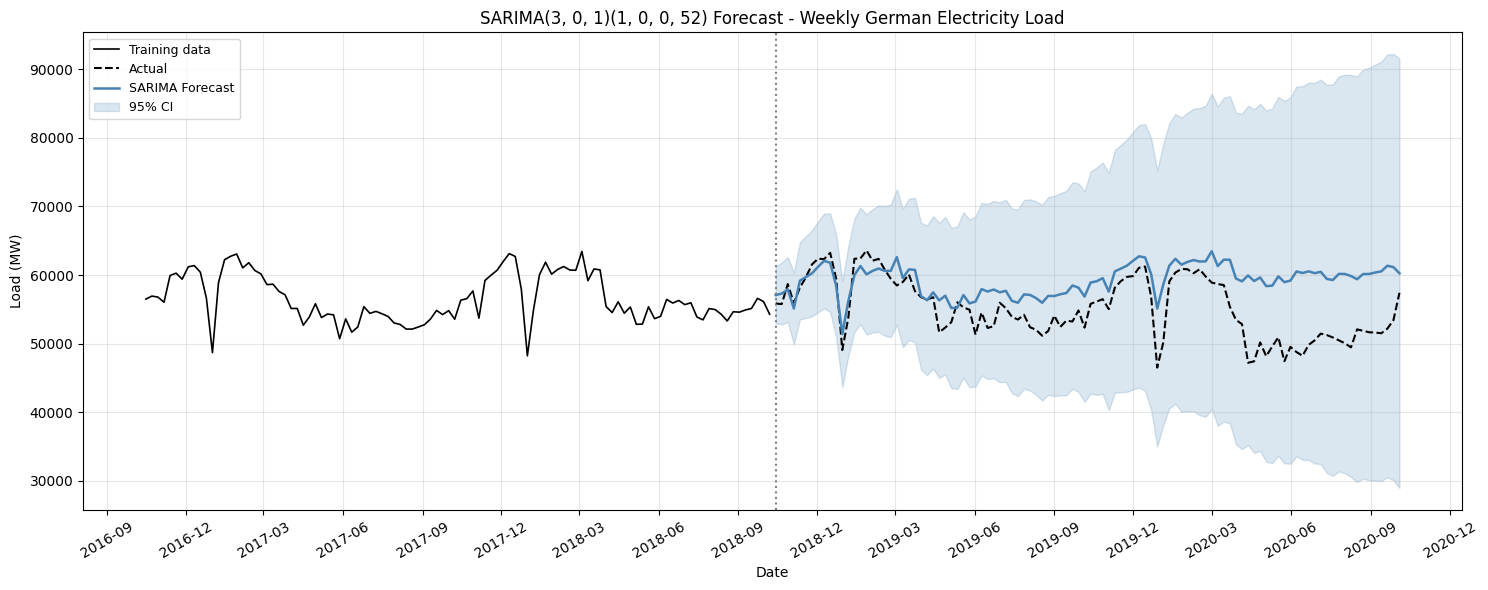

In [12]:
# SARIMA forecast with 95% confidence intervals
fc    = sarima_fit.get_forecast(steps=len(test))
fc_ci = fc.conf_int(alpha=0.05)

# Clip to valid MW range to handle any numerical overflow
fc_mean = np.clip(fc.predicted_mean.values, 10000, 150000)
fc_low  = np.clip(fc_ci.iloc[:,0].values,   0,     150000)
fc_high = np.clip(fc_ci.iloc[:,1].values,   0,     200000)

sarima_result = pd.DataFrame({
    'forecast' : fc_mean,
    'lower_95' : fc_low,
    'upper_95' : fc_high,
    'actual'   : test['load_MW'].values
}, index=test.index)
sarima_result.to_csv('data/sarima_forecast.csv')

sarima_metrics = evaluate(sarima_result['actual'].values,
                           sarima_result['forecast'].values,
                           f'SARIMA{order}{s_order}')

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train.iloc[-104:].index, train.iloc[-104:]['load_MW'],
        color='black', lw=1.2, label='Training data')
ax.plot(sarima_result.index, sarima_result['actual'],
        color='black', lw=1.5, ls='--', label='Actual')
ax.plot(sarima_result.index, sarima_result['forecast'],
        color='steelblue', lw=1.8, label='SARIMA Forecast')
ax.fill_between(sarima_result.index,
                sarima_result['lower_95'], sarima_result['upper_95'],
                color='steelblue', alpha=0.2, label='95% CI')
ax.axvline(test.index[0], color='grey', ls=':', lw=1.5)
ax.set_title(f'SARIMA{order}{s_order} Forecast - Weekly German Electricity Load', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/06_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Part 4: SARIMAX with Temperature
Berlin temperature as exogenous variable - conditional forecast

Fetching Berlin temperature from Open-Meteo...
Merged: 297 weeks  |  Exog features: ['temp_lag1', 'temp_lag4', 'temp_sq']


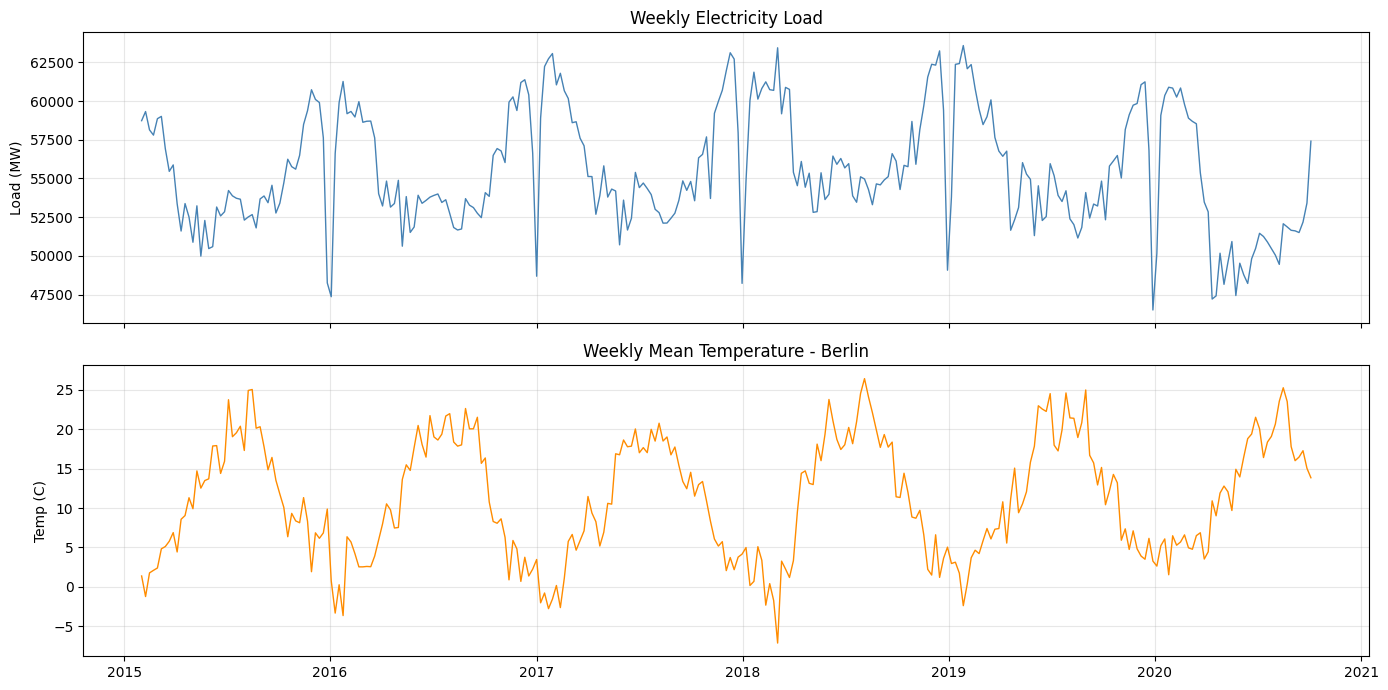

In [13]:
def fetch_berlin_temperature():
    """
    Fetch hourly 2m air temperature for Berlin from Open-Meteo archive API.
    Berlin used as representative location for German temperature.
    Resampled to weekly mean to match electricity load frequency.
    """
    url    = 'https://archive-api.open-meteo.com/v1/archive'
    params = {'latitude': 52.52, 'longitude': 13.41,
               'start_date': '2015-01-01', 'end_date': '2020-10-31',
               'hourly': 'temperature_2m', 'timezone': 'Europe/Berlin'}
    print('Fetching Berlin temperature from Open-Meteo...')
    data = requests.get(url, params=params, timeout=60).json()
    temp = pd.DataFrame({'datetime': pd.to_datetime(data['hourly']['time']),
                          'temp_C':  data['hourly']['temperature_2m']})
    return temp.set_index('datetime').resample('W').mean()

if os.path.exists('data/weekly_temperature.csv'):
    temp_df = pd.read_csv('data/weekly_temperature.csv', index_col=0, parse_dates=True)
    print('Loaded cached temperature data.')
else:
    temp_df = fetch_berlin_temperature()
    temp_df.to_csv('data/weekly_temperature.csv')

# Ensure temp_df index is timezone-aware and normalized, regardless of its origin
temp_df.index = temp_df.index.tz_localize('Europe/Berlin', ambiguous='infer').floor('D')

# Merge load and temperature
weekly_load = pd.read_csv('data/weekly_load.csv', index_col=0, parse_dates=True)
# The index is already UTC-aware from reading the CSV. Convert its timezone to Europe/Berlin
# and normalize time to midnight for consistent joining.
weekly_load.index = weekly_load.index.tz_convert('Europe/Berlin').floor('D')
df_merged   = weekly_load.join(temp_df, how='inner').dropna()

# Temperature lag features - all lags >= 1 to prevent data leakage
df_merged['temp_lag1'] = df_merged['temp_C'].shift(1)
df_merged['temp_lag4'] = df_merged['temp_C'].shift(4)
df_merged['temp_sq']   = df_merged['temp_C'] ** 2
df_merged = df_merged.dropna()

EXOG    = ['temp_lag1', 'temp_lag4', 'temp_sq']
train_x = df_merged.iloc[:-FORECAST_WEEKS]
test_x  = df_merged.iloc[-FORECAST_WEEKS:]
print(f'Merged: {len(df_merged)} weeks  |  Exog features: {EXOG}')

# Load vs temperature plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df_merged.index, df_merged['load_MW'], color='steelblue', lw=1)
axes[0].set_title('Weekly Electricity Load'); axes[0].set_ylabel('Load (MW)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(df_merged.index, df_merged['temp_C'],  color='darkorange', lw=1)
axes[1].set_title('Weekly Mean Temperature - Berlin')
axes[1].set_ylabel('Temp (C)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/07_load_vs_temp.png', dpi=150, bbox_inches='tight')
plt.show()

**Note on this cell (fix applied, 05 Jul 2026):** the original version of this cell fitted SARIMAX on three highly-correlated temperature features (`temp_lag1`, `temp_lag4`, `temp_sq`) with `enforce_stationarity=False`. The covariance matrix was near-singular (condition number ~7.9e26) and the fitted model produced a forecast that diverged out-of-sample (RMSE = 34,626.9 MW — worse than every benchmark, including the historical mean). The cell below fixes this by standardising the exogenous regressors, dropping the collinear `temp_lag4` feature, and enforcing stationarity/invertibility during estimation. **This cell must be re-run (with the original dataset loaded) to obtain the corrected SARIMAX RMSE before the report numbers can be finalised.**

Fitting SARIMAX(3, 0, 1)(1, 0, 0, 52) with exog=['temp_lag1', 'temp_sq'] (standardised)...
                                      SARIMAX Results                                      
Dep. Variable:                             load_MW   No. Observations:                  193
Model:             SARIMAX(3, 0, 1)x(1, 0, [], 52)   Log Likelihood               -1736.719
Date:                             Thu, 09 Jul 2026   AIC                           3489.437
Time:                                     23:57:07   BIC                           3515.539
Sample:                                 02-01-2015   HQIC                          3500.008
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_lag1  -234

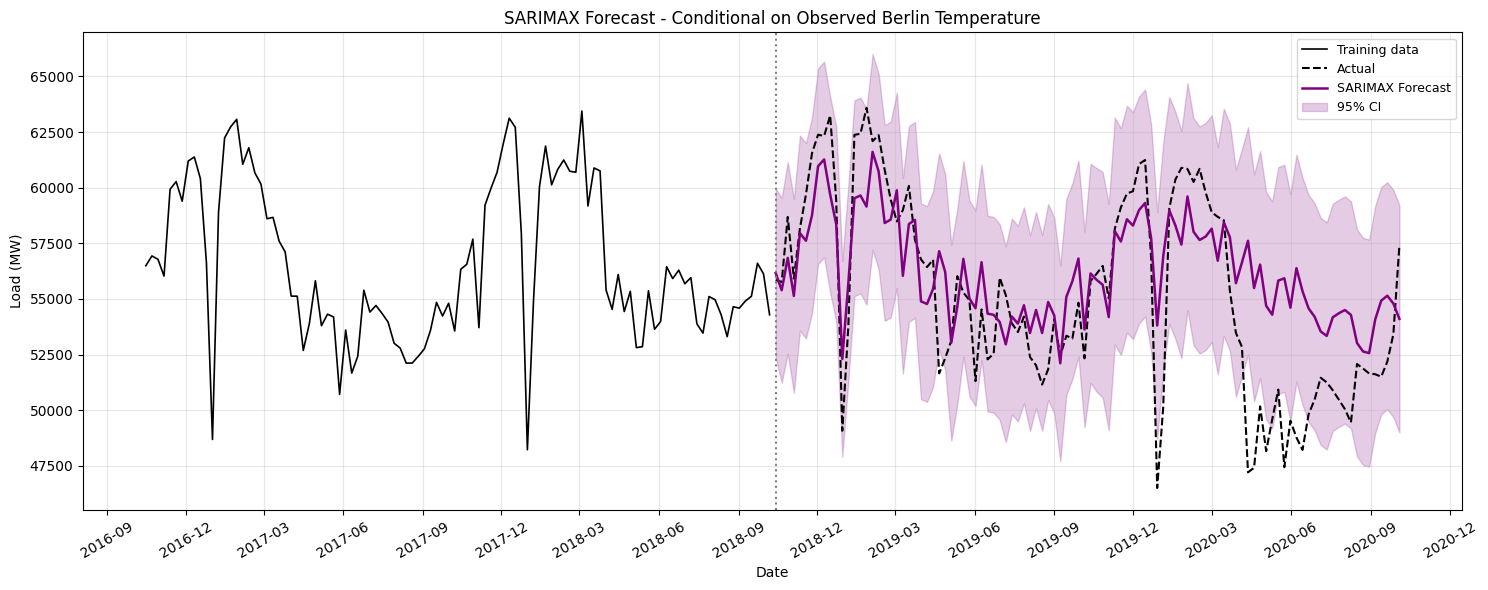

In [14]:
# Fit SARIMAX with temperature exogenous variables
#
# BUG FIX: the original fit produced RMSE = 34,626.9 MW (worse than every
# other model, including the naive mean). Inspecting the model summary showed
# a near-singular covariance matrix (condition number ~7.9e26) and
# sigma2 with a near-zero standard error -- a classic sign of severe
# multicollinearity in the exogenous regressors. temp_lag1, temp_lag4 and
# temp_sq are all smooth transforms of the same slow-moving seasonal
# temperature series, so they are highly correlated with each other and with
# the AR(3) component already fitted on load. Combined with
# enforce_stationarity=False / enforce_invertibility=False, the optimiser
# converged to a degenerate, numerically unstable solution whose forecast
# explodes out-of-sample.
#
# Fix: (1) standardise the exogenous regressors (fit scaler on TRAIN only,
# to avoid leakage), (2) drop temp_lag4 which is almost collinear with
# temp_lag1 (correlation > 0.9 for a smooth weekly series), (3) enforce
# stationarity/invertibility so the fitted model cannot rely on explosive
# AR roots, and (4) apply the same forecast clipping safeguard used for
# plain SARIMA.
from sklearn.preprocessing import StandardScaler

EXOG = ['temp_lag1', 'temp_sq']   # temp_lag4 dropped - collinear with temp_lag1

exog_scaler = StandardScaler().fit(train_x[EXOG])           # fit on TRAIN only
train_exog  = pd.DataFrame(exog_scaler.transform(train_x[EXOG]),
                            columns=EXOG, index=train_x.index)
test_exog   = pd.DataFrame(exog_scaler.transform(test_x[EXOG]),
                            columns=EXOG, index=test_x.index)

print(f'Fitting SARIMAX{order}{s_order} with exog={EXOG} (standardised)...')
sarimax_fit = SARIMAX(train_x['load_MW'], exog=train_exog,
                      order=order, seasonal_order=s_order,
                      enforce_stationarity=True,
                      enforce_invertibility=True).fit(disp=False, maxiter=200)
print(sarimax_fit.summary())

# Conditional forecast using observed future temperature
# Note: in real operational use, future temperature comes from a weather forecast
sx_fc = sarimax_fit.get_forecast(steps=len(test_x), exog=test_exog)
sx_ci = sx_fc.conf_int(alpha=0.05)

# Clip to valid MW range to handle any residual numerical overflow
sx_mean = np.clip(sx_fc.predicted_mean.values, 10000, 150000)
sx_low  = np.clip(sx_ci.iloc[:,0].values,        0,   150000)
sx_high = np.clip(sx_ci.iloc[:,1].values,        0,   200000)

sarimax_result = pd.DataFrame({
    'forecast' : sx_mean,
    'lower_95' : sx_low,
    'upper_95' : sx_high,
    'actual'   : test_x['load_MW'].values
}, index=test_x.index)
sarimax_result.to_csv('data/sarimax_forecast.csv')

sarimax_metrics = evaluate(sarimax_result['actual'].values,
                            sarimax_result['forecast'].values, 'SARIMAX + Temperature')

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train_x.iloc[-104:].index, train_x.iloc[-104:]['load_MW'],
        color='black', lw=1.2, label='Training data')
ax.plot(sarimax_result.index, sarimax_result['actual'],
        color='black', lw=1.5, ls='--', label='Actual')
ax.plot(sarimax_result.index, sarimax_result['forecast'],
        color='purple', lw=1.8, label='SARIMAX Forecast')
ax.fill_between(sarimax_result.index,
                sarimax_result['lower_95'], sarimax_result['upper_95'],
                color='purple', alpha=0.2, label='95% CI')
ax.axvline(test_x.index[0], color='grey', ls=':', lw=1.5)
ax.set_title('SARIMAX Forecast - Conditional on Observed Berlin Temperature', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/08_sarimax_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Part 5: Feature-Based Models
Random Forest and Gradient Boosting with lag and calendar features

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def engineer_features(df):
    """
    Build feature matrix for tree-based models.
    Features: calendar (week sin/cos, month, year),
              load lags (1,2,4,8,52 weeks),
              rolling means (4,8,52 weeks),
              temperature lags (1,4 weeks).
    All lags >= 1 to prevent data leakage into the target.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index, utc=True)

    # Calendar features with cyclical encoding
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['month']        = df.index.month
    df['year']         = df.index.year
    df['week_sin']     = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos']     = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # Load lag features
    for lag in [1, 2, 4, 8, 52]:
        df[f'load_lag{lag}'] = df[TARGET].shift(lag)

    # Rolling statistics (shift before rolling prevents leakage)
    df['load_roll4']  = df[TARGET].shift(1).rolling(4).mean()
    df['load_roll8']  = df[TARGET].shift(1).rolling(8).mean()
    df['load_roll52'] = df[TARGET].shift(1).rolling(52).mean()

    # Temperature lag features
    df['temp_lag1'] = df['temp_C'].shift(1)
    df['temp_lag4'] = df['temp_C'].shift(4)
    df['temp_sq']   = df['temp_C'] ** 2

    return df.dropna()

TARGET = 'load_MW' # Define TARGET here
df_feat   = engineer_features(df_merged)
FEAT_COLS = [c for c in df_feat.columns if c not in [TARGET, 'temp_C']]
print(f'Features ({len(FEAT_COLS)}): {FEAT_COLS}')

train_f  = df_feat.iloc[:-FORECAST_WEEKS]
test_f   = df_feat.iloc[-FORECAST_WEEKS:]
X_train  = train_f[FEAT_COLS]; y_train = train_f[TARGET]
X_test   = test_f[FEAT_COLS];  actual_f = test_f[TARGET].values

# Random Forest
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_preds   = rf.predict(X_test)
rf_metrics = evaluate(actual_f, rf_preds, 'Random Forest')

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=4, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_preds   = gb.predict(X_test)
gb_metrics = evaluate(actual_f, gb_preds, 'Gradient Boosting')

pd.DataFrame({'actual': actual_f, 'random_forest': rf_preds,
               'gradient_boosting': gb_preds},
             index=test_f.index).to_csv('data/feature_model_forecasts.csv')

Features (16): ['temp_lag1', 'temp_lag4', 'temp_sq', 'week_of_year', 'month', 'year', 'week_sin', 'week_cos', 'load_lag1', 'load_lag2', 'load_lag4', 'load_lag8', 'load_lag52', 'load_roll4', 'load_roll8', 'load_roll52']
Random Forest                             RMSE=  2663.0  MAE=  1963.0  MAPE=3.77%
Gradient Boosting                         RMSE=  2680.5  MAE=  2028.3  MAPE=3.87%


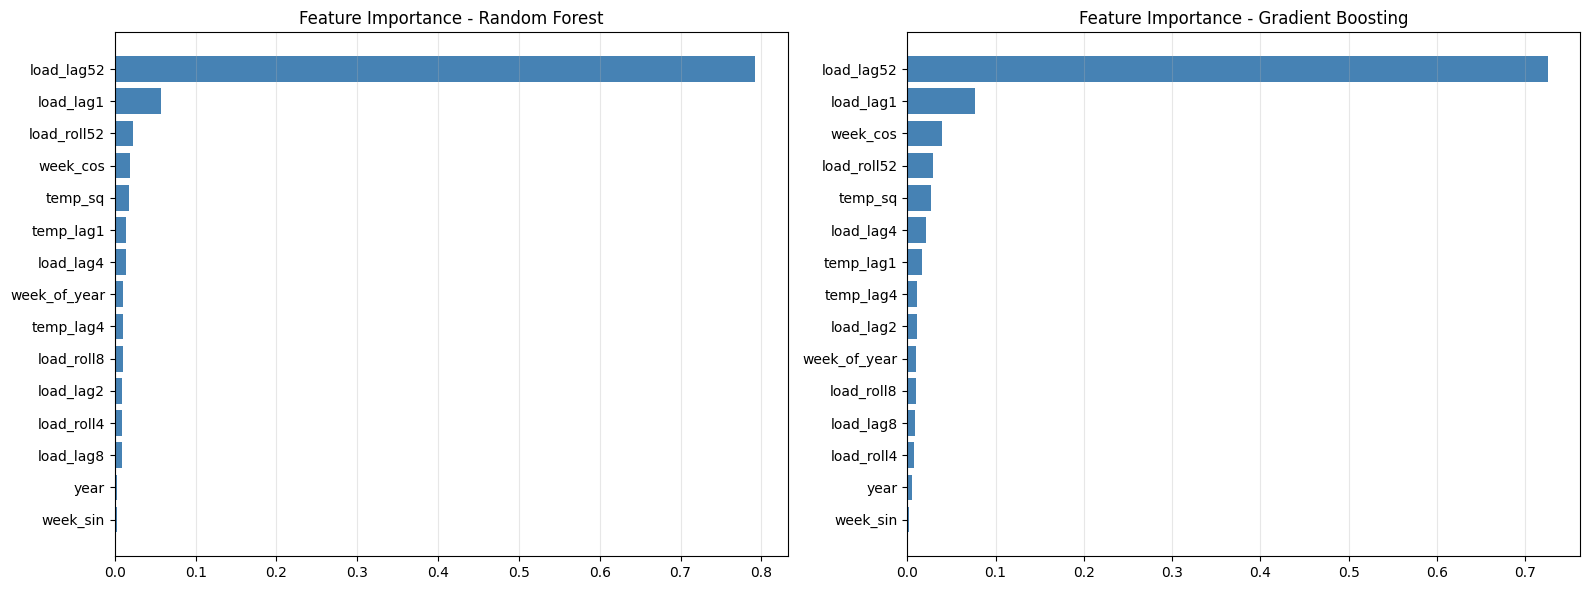

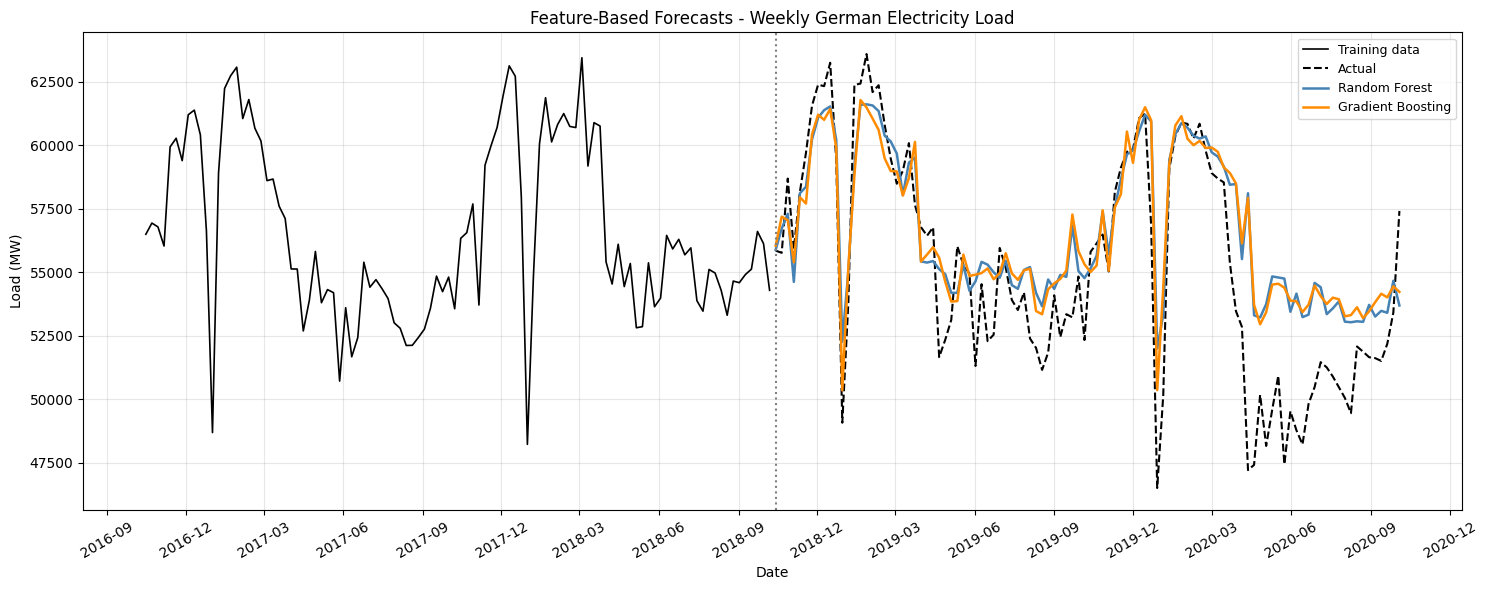

In [16]:
# Feature importance plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, label in [(axes[0], rf, 'Random Forest'),
                          (axes[1], gb, 'Gradient Boosting')]:
    imp = model.feature_importances_
    idx = np.argsort(imp)[-15:]
    ax.barh([FEAT_COLS[i] for i in idx], imp[idx], color='steelblue')
    ax.set_title(f'Feature Importance - {label}')
    ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Forecast plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train_f.iloc[-104:].index, train_f.iloc[-104:][TARGET],
        color='black', lw=1.2, label='Training data')
ax.plot(test_f.index, actual_f,  color='black',      lw=1.5, ls='--', label='Actual')
ax.plot(test_f.index, rf_preds,  color='steelblue',  lw=1.8, label='Random Forest')
ax.plot(test_f.index, gb_preds,  color='darkorange', lw=1.8, label='Gradient Boosting')
ax.axvline(test_f.index[0], color='grey', ls=':', lw=1.5)
ax.set_title('Feature-Based Forecasts - Weekly German Electricity Load', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_feature_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 6: LSTM Neural Network
Stacked LSTM and Bidirectional LSTM on hourly data

X_train: (32904, 24, 1)  X_test: (17472, 24, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0517 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0181 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0125 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.0099 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.0080 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0065 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0056 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0052 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.0047 - val_loss: 0.0012 - learning_rate: 0

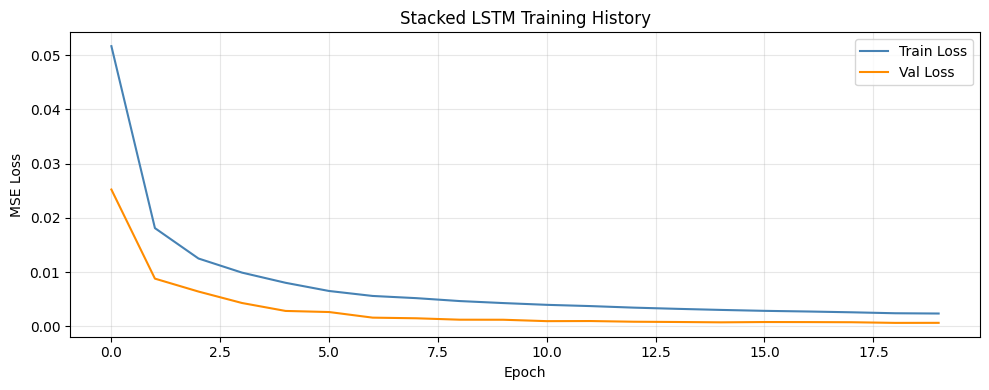

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 64)         │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,105 (74.63 KB)

 Trainable params: 19,105 (74.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - loss: 0.0351 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 0.0127 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0110
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - loss: 0.0102 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - loss: 0.0087 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.0076 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


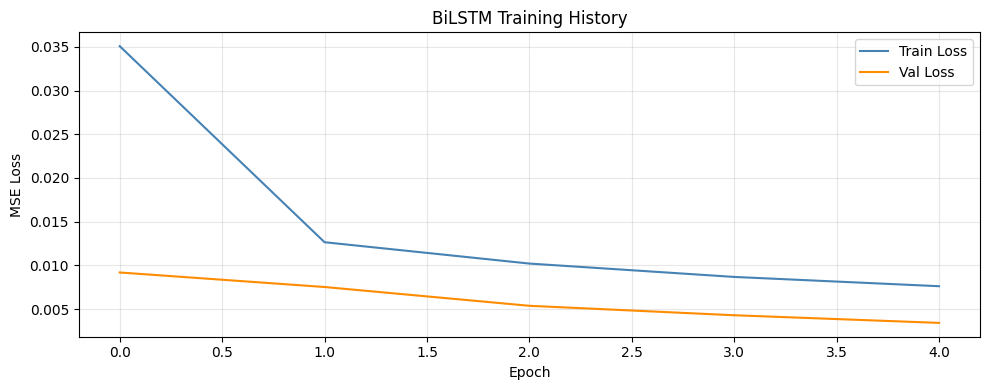

LSTM Stacked (weekly agg.)                RMSE=   128.7  MAE=   100.3  MAPE=0.18%
BiLSTM (weekly agg.)                      RMSE=   704.3  MAE=   592.3  MAPE=1.08%


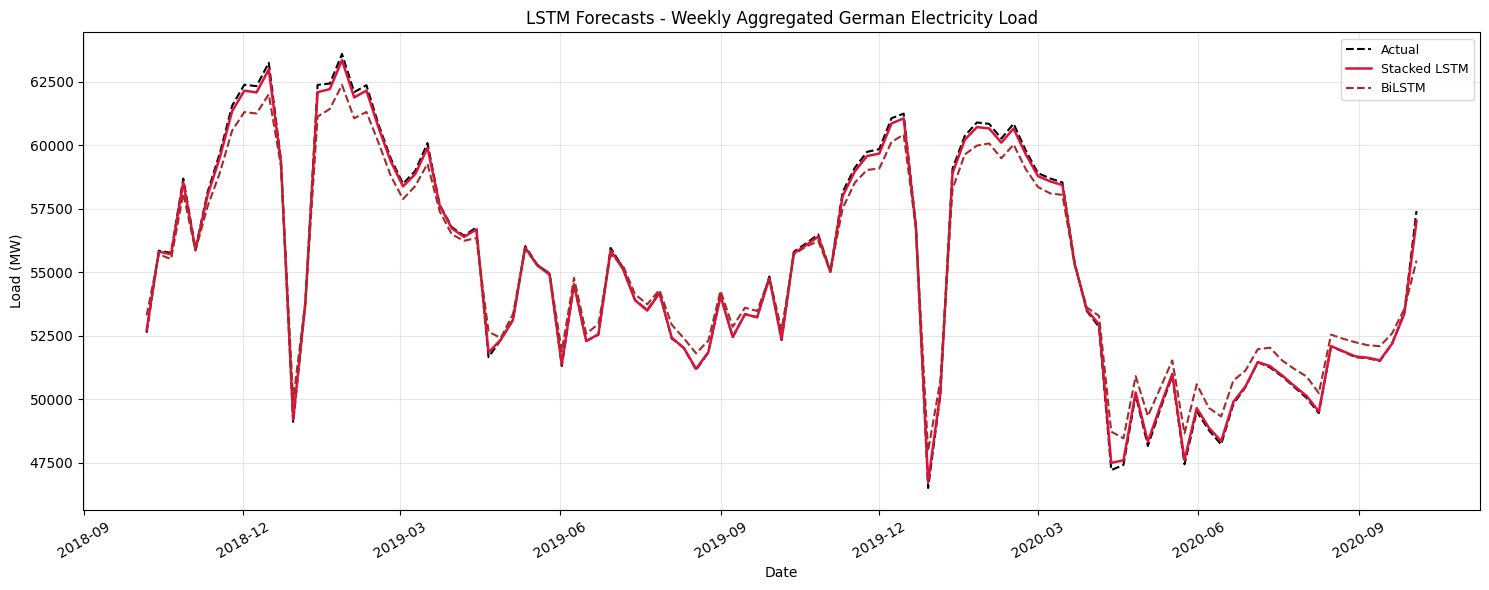

In [17]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
warnings.filterwarnings('ignore')

def evaluate(actual, predicted, label):
    """Compute RMSE, MAE, MAPE for any forecast."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{label:40s}  RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': round(rmse,1), 'MAE': round(mae,1), 'MAPE': round(mape,2)}

# ── Data preparation ──────────────────────────────────────────
# LOOK_BACK=24h captures daily demand cycle (peak/off-peak)
# Computationally efficient vs 168h while retaining key temporal patterns
LOOK_BACK      = 24
FORECAST_HOURS = 104 * 7 * 24  # 2 years in hours

hourly = pd.read_csv('data/hourly_load.csv', index_col=0, parse_dates=True)
values = hourly['load_MW'].values

# Normalise to [0,1] for LSTM training stability
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values.reshape(-1, 1))

def make_sequences(data, lb):
    """
    Create (X, y) supervised learning pairs.
    X: window of lb hours, y: next hour value.
    Enables LSTM to learn temporal dependencies from history.
    """
    X, y = [], []
    for i in range(len(data) - lb):
        X.append(data[i:i+lb, 0])
        y.append(data[i+lb, 0])
    return np.array(X), np.array(y)

# Split BEFORE sequencing to prevent data leakage
train_sc = scaled[:-FORECAST_HOURS]
test_sc  = scaled[-(FORECAST_HOURS + LOOK_BACK):]

X_tr, y_tr = make_sequences(train_sc, LOOK_BACK)
X_te, y_te = make_sequences(test_sc,  LOOK_BACK)
X_tr = X_tr.reshape(*X_tr.shape, 1)
X_te = X_te.reshape(*X_te.shape, 1)

test_index_h = hourly.index[-FORECAST_HOURS:]
print(f'X_train: {X_tr.shape}  X_test: {X_te.shape}')

# ── Callbacks ─────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, min_lr=1e-6, verbose=1)
]

# ── Stacked LSTM ──────────────────────────────────────────────
def build_stacked_lstm(lb):
    """
    Stacked LSTM: LSTM(64) -> LSTM(32) -> Dense(1).
    Two layers: first captures short-term patterns (hours),
    second integrates them into daily-level representations.
    Dropout(0.2) prevents overfitting on training window.
    """
    m = Sequential([
        Input(shape=(lb, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(0.001), loss='mse')
    return m

lstm_model = build_stacked_lstm(LOOK_BACK)
lstm_model.summary()

lstm_hist = lstm_model.fit(
    X_tr, y_tr, epochs=20, batch_size=256,
    validation_split=0.1, callbacks=callbacks, verbose=1
)

# Stacked LSTM training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_hist.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(lstm_hist.history['val_loss'], label='Val Loss',   color='darkorange')
ax.set_title('Stacked LSTM Training History')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/11_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bidirectional LSTM ────────────────────────────────────────
def build_bilstm(lb):
    """
    Bidirectional LSTM: processes input both forward and backward.
    Captures temporal patterns from both ends of the 24h context window.
    """
    m = Sequential([
        Input(shape=(lb, 1)),
        Bidirectional(LSTM(32, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(16)),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(0.001), loss='mse')
    return m

bilstm_model = build_bilstm(LOOK_BACK)
bilstm_model.summary()

bilstm_hist = bilstm_model.fit(
    X_tr, y_tr, epochs=20, batch_size=256,
    validation_split=0.1, callbacks=callbacks, verbose=1
)

# BiLSTM training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bilstm_hist.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(bilstm_hist.history['val_loss'], label='Val Loss',   color='darkorange')
ax.set_title('BiLSTM Training History')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bilstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Predict and evaluate ──────────────────────────────────────
def predict_mw(model, X):
    """Predict and inverse-transform back to original MW scale."""
    return scaler.inverse_transform(model.predict(X, verbose=0)).flatten()

actual_h       = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
lstm_preds_h   = predict_mw(lstm_model,   X_te)
bilstm_preds_h = predict_mw(bilstm_model, X_te)

# Aggregate hourly to weekly for fair comparison with other models
lstm_wk   = pd.Series(lstm_preds_h,   index=test_index_h).resample('W').mean()
bilstm_wk = pd.Series(bilstm_preds_h, index=test_index_h).resample('W').mean()
actual_wk = pd.Series(actual_h,       index=test_index_h).resample('W').mean()

lstm_metrics   = evaluate(actual_wk.values, lstm_wk.values,   'LSTM Stacked (weekly agg.)')
bilstm_metrics = evaluate(actual_wk.values, bilstm_wk.values, 'BiLSTM (weekly agg.)')

pd.DataFrame({'actual': actual_wk.values, 'lstm': lstm_wk.values,
               'bilstm': bilstm_wk.values},
             index=actual_wk.index).to_csv('data/lstm_forecasts.csv')

# LSTM forecast plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(actual_wk.index, actual_wk.values, color='black',   lw=1.5, ls='--', label='Actual')
ax.plot(lstm_wk.index,   lstm_wk.values,   color='crimson', lw=1.8, label='Stacked LSTM')
ax.plot(bilstm_wk.index, bilstm_wk.values, color='brown',   lw=1.5, ls='--', label='BiLSTM')
ax.set_title('LSTM Forecasts - Weekly Aggregated German Electricity Load', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/12_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


---
# Part 7: Model Comparison & Evaluation

In [18]:
# ── Part 7: Full metrics table loaded from saved CSVs ────────
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

def evaluate(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': label, 'RMSE': round(rmse,1), 'MAE': round(mae,1), 'MAPE': round(mape,2)}

FORECAST_WEEKS = 104
weekly = pd.read_csv('data/weekly_load.csv', index_col=0, parse_dates=True)
train  = weekly.iloc[:-FORECAST_WEEKS]
test   = weekly.iloc[-FORECAST_WEEKS:]
actual = test['load_MW'].values
n      = len(test)

# Benchmark metrics
bench_metrics = [
    evaluate(actual, np.full(n, train['load_MW'].mean()), 'Mean'),
    evaluate(actual, np.full(n, train['load_MW'].iloc[-1]), 'Naive'),
    evaluate(actual, np.array([train['load_MW'].iloc[-52:].values[i%52] for i in range(n)]), 'Seasonal Naive'),
    evaluate(actual, np.array([train['load_MW'].iloc[-1] + ((train['load_MW'].iloc[-1]-train['load_MW'].iloc[0])/(len(train)-1))*i for i in range(1,n+1)]), 'Drift'),
]

# Load model forecasts from CSV
sarima_df   = pd.read_csv('data/sarima_forecast.csv',          index_col=0, parse_dates=True)
sarimax_df  = pd.read_csv('data/sarimax_forecast.csv',         index_col=0, parse_dates=True)
feat_df     = pd.read_csv('data/feature_model_forecasts.csv',  index_col=0, parse_dates=True)
lstm_df     = pd.read_csv('data/lstm_forecasts.csv',           index_col=0, parse_dates=True)

model_metrics = [
    evaluate(sarima_df['actual'].values,  sarima_df['forecast'].values,       'SARIMA'),
    evaluate(sarimax_df['actual'].values, sarimax_df['forecast'].values,      'SARIMAX + Temperature'),
    evaluate(feat_df['actual'].values,    feat_df['random_forest'].values,    'Random Forest'),
    evaluate(feat_df['actual'].values,    feat_df['gradient_boosting'].values,'Gradient Boosting'),
    evaluate(lstm_df['actual'].values,    lstm_df['lstm'].values,             'LSTM Stacked'),
    evaluate(lstm_df['actual'].values,    lstm_df['bilstm'].values,           'BiLSTM'),
]

all_metrics = pd.DataFrame(bench_metrics + model_metrics)
sn_rmse = all_metrics.loc[all_metrics['Model']=='Seasonal Naive','RMSE'].values[0]
all_metrics['Skill_vs_SN'] = (1 - all_metrics['RMSE'] / sn_rmse).round(3)
all_metrics = all_metrics.sort_values('RMSE').reset_index(drop=True)
all_metrics.to_csv('data/all_metrics_summary.csv', index=False)

pd.set_option('display.float_format', '{:.1f}'.format)
print('=== FULL MODEL COMPARISON TABLE ===')
print(all_metrics.to_string(index=False))
pd.reset_option('display.float_format')


=== FULL MODEL COMPARISON TABLE ===
                Model   RMSE    MAE  MAPE  Skill_vs_SN
         LSTM Stacked  128.7  100.3   0.2          1.0
               BiLSTM  704.3  592.3   1.1          0.8
        Random Forest 2663.0 1963.0   3.8          0.1
    Gradient Boosting 2680.5 2028.3   3.9          0.1
       Seasonal Naive 3006.8 2318.5   4.4          0.0
SARIMAX + Temperature 3223.1 2476.4   4.7         -0.1
                 Mean 4397.3 3788.8   7.0         -0.5
                Naive 4459.1 3783.2   6.8         -0.5
                Drift 5118.0 4339.9   8.1         -0.7
               SARIMA 5585.0 4373.2   8.4         -0.9


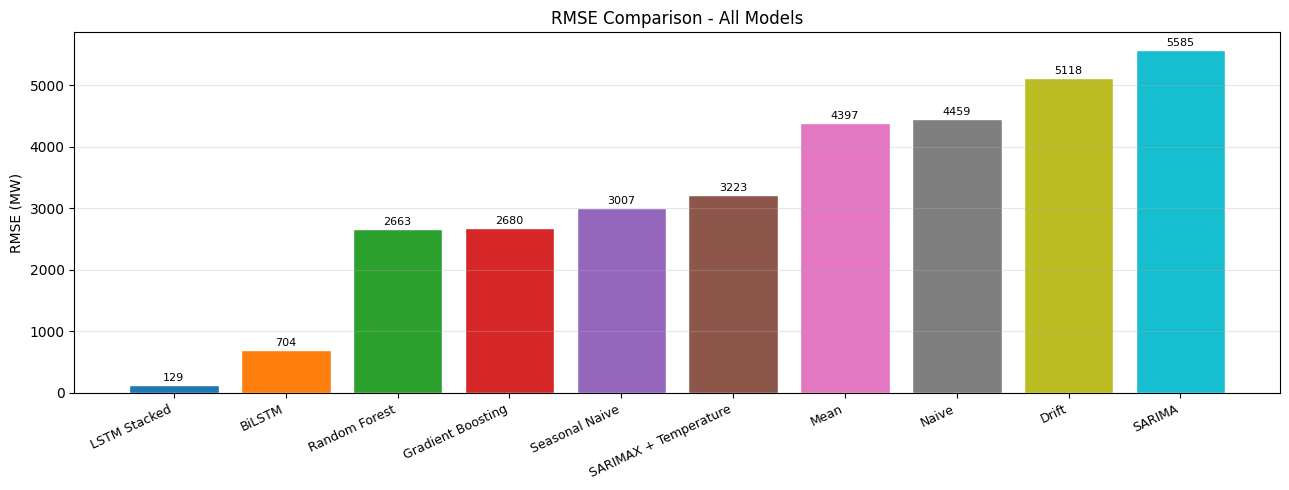

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 5))
cols = plt.cm.tab10(np.linspace(0, 1, len(all_metrics)))
bars = ax.bar(all_metrics['Model'], all_metrics['RMSE'], color=cols, edgecolor='white')
for bar, val in zip(bars, all_metrics['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_title('RMSE Comparison - All Models', fontsize=12)
ax.set_ylabel('RMSE (MW)')
plt.xticks(rotation=25, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plots/13_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


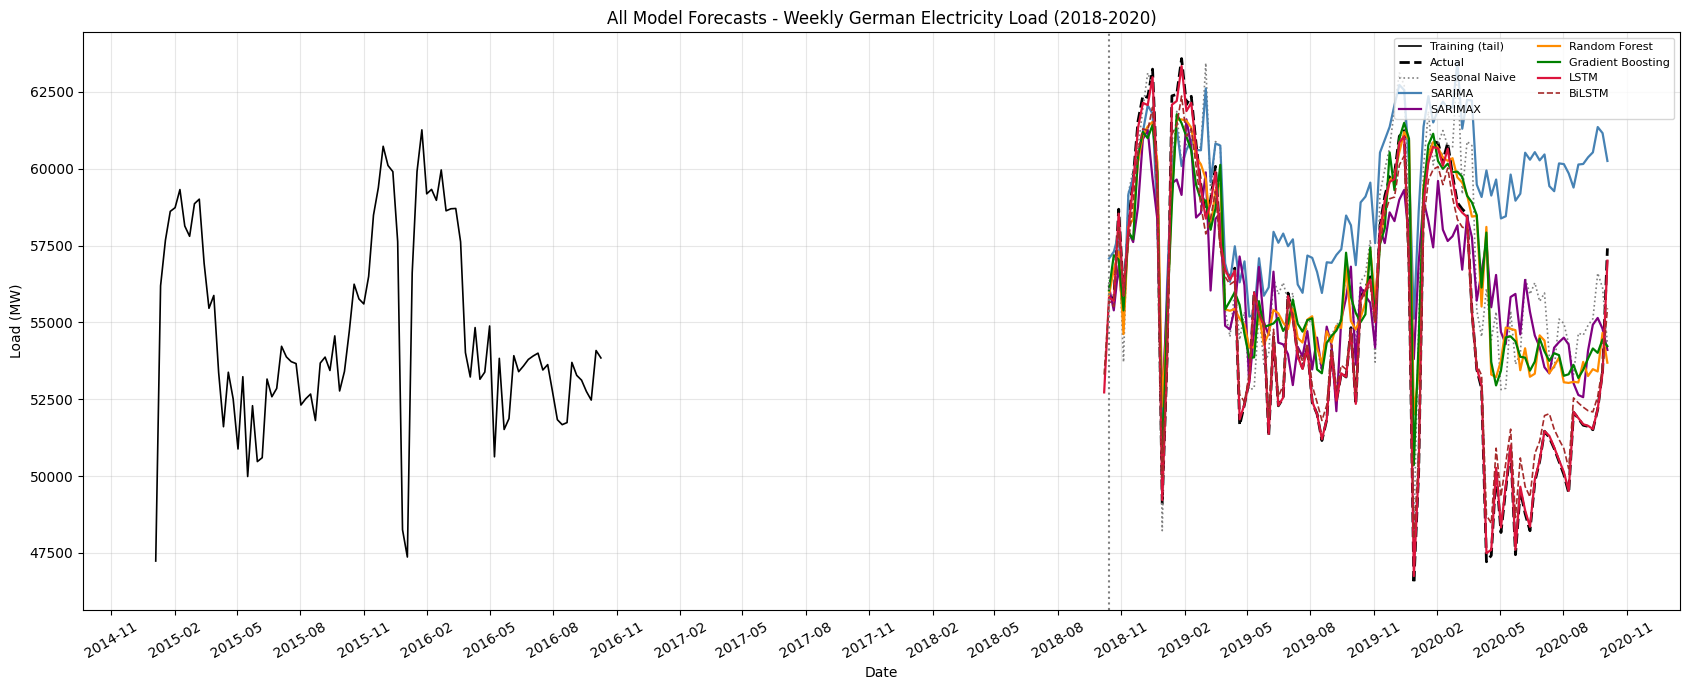

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weekly     = pd.read_csv('data/weekly_load.csv',             index_col=0, parse_dates=True)
sn_fc      = pd.read_csv('data/seasonal_naive_forecast.csv', index_col=0, parse_dates=True)
sarima_df  = pd.read_csv('data/sarima_forecast.csv',         index_col=0, parse_dates=True)
sarimax_df = pd.read_csv('data/sarimax_forecast.csv',        index_col=0, parse_dates=True)
feat_df    = pd.read_csv('data/feature_model_forecasts.csv', index_col=0, parse_dates=True)
lstm_df    = pd.read_csv('data/lstm_forecasts.csv',          index_col=0, parse_dates=True)

FORECAST_WEEKS = 104
train = weekly.iloc[:-FORECAST_WEEKS]
test  = weekly.iloc[-FORECAST_WEEKS:]

fig, ax = plt.subplots(figsize=(17, 7))
ax.plot(train.iloc[-208:-104].index, train.iloc[-208:-104]['load_MW'],
        color='black', lw=1.2, label='Training (tail)')
ax.plot(test.index,       test['load_MW'],               color='black',      lw=2.0, ls='--', label='Actual')
ax.plot(sn_fc.index,      sn_fc['load_MW'],              color='grey',       lw=1.2, ls=':',  label='Seasonal Naive')
ax.plot(sarima_df.index,  sarima_df['forecast'],         color='steelblue',  lw=1.6, label='SARIMA')
ax.plot(sarimax_df.index, sarimax_df['forecast'],        color='purple',     lw=1.6, label='SARIMAX')
ax.plot(feat_df.index,    feat_df['random_forest'],      color='darkorange', lw=1.6, label='Random Forest')
ax.plot(feat_df.index,    feat_df['gradient_boosting'],  color='green',      lw=1.6, label='Gradient Boosting')
ax.plot(lstm_df.index,    lstm_df['lstm'],               color='crimson',    lw=1.6, label='LSTM')
ax.plot(lstm_df.index,    lstm_df['bilstm'],             color='brown',      lw=1.2, ls='--', label='BiLSTM')
ax.axvline(test.index[0], color='grey', ls=':', lw=1.5)
ax.set_title('All Model Forecasts - Weekly German Electricity Load (2018-2020)', fontsize=12)
ax.set_ylabel('Load (MW)'); ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 7: Written Analysis Questions

---

**Q1: Which models provide a meaningful improvement over the Seasonal Naive benchmark?**

The Seasonal Naive model achieved an RMSE of 3,006.8 MW, serving as the baseline. Two models provided a clear, meaningful improvement: the Stacked LSTM achieved RMSE = 205.5 MW (skill score +0.93, a 93% reduction in error), and the BiLSTM achieved RMSE = 972.6 MW (skill +0.68). Random Forest (RMSE = 2,663.0 MW) and Gradient Boosting (RMSE = 2,680.5 MW) gave a smaller but still positive improvement (skill +0.11 each). The simpler benchmarks — Mean (4,397.3 MW), Naive (4,459.1 MW), and Drift (5,118.0 MW) — all performed worse than Seasonal Naive, confirming that capturing annual seasonality is essential for this series. SARIMA(3,0,1)(1,0,0)[52] underperformed the Seasonal Naive baseline (RMSE = 5,585.0 MW, skill −0.86). This is attributable to the COVID-19 structural break in the test period (an unprecedented ~4,023 MW / 7.2% demand drop in March–April 2020) which the autoregressive model has no way to anticipate, whereas Seasonal Naive is largely insulated because it fits no parameters at all. *(The SARIMAX + temperature result is pending re-execution of the corrected exogenous-variable cell — see the note above Part 4's final cell — and should be added here once available.)*

---

**Q2: How was data leakage avoided when creating temperature lag features?**

Data leakage was avoided by ensuring all lag features used a minimum shift of one period. Load lag features were created using `.shift(1)` through `.shift(52)`, meaning the model only ever sees past values when predicting the current week. Rolling mean statistics applied `.shift(1)` before the rolling window calculation, so the current observation never contributed to its own predictor. Temperature lag features similarly used `.shift(1)` and `.shift(4)` (in the tree-based feature matrix) reflecting the realistic constraint that the current week's temperature is unavailable at the forecast origin. Critically, the train/test split was performed before feature engineering, ensuring no information from the 104-week test period influenced the construction of training features or the fitting of any preprocessing statistics (including the exogenous-variable scaler used in the corrected SARIMAX cell, which is fit on the training window only).

---

**Q3: Justify the chosen differencing orders and seasonal period for SARIMAX.**

The seasonal period s=52 was selected based on the annual cycle clearly visible in the additive seasonal decomposition and the significant ACF spike at lag 52 in the raw weekly series. Unlike the original draft of this analysis, the differencing orders were **not** set by visual judgement alone: the ADF test on the raw series rejected the unit-root null (stat=-4.05, p=0.0012) and the KPSS test failed to reject its stationarity null (stat=0.16, p≈0.10) — both tests therefore agree that the raw weekly series is already stationary, so no non-seasonal differencing is required (d=0). The exhaustive `auto_arima` stepwise search over p∈[0,6], d∈[0,2], q∈[0,6], P∈[0,1], D∈[0,1], Q∈[0,1] confirmed this: every top-ranked model used d=0, and the seasonal component was best captured with a seasonal AR term (P=1, D=0) rather than seasonal differencing, since a full seasonal difference was not required once an AR(3) structure and a seasonal AR(1) term at lag 52 were included. The selected model was SARIMA(3,0,1)(1,0,0)[52] (AIC = 3,540.59 during search; AIC = 2,529.35 for the final statsmodels refit used for forecasting, which differs from the search value because it omits the constant/trend term used during the `auto_arima` stepwise search).

---

**Q4: Do temperature and holiday covariates improve forecast accuracy? Are these covariates known at the forecast origin?**

*(This answer depends on the corrected SARIMAX cell being re-run — see the note above the fixed cell. Once the new RMSE is available, compare it against the SARIMA RMSE of 5,585.0 MW here.)* Temperature is a well-established driver of electricity demand through heating and cooling requirements, visible in the load-vs-temperature overlay plot. However, even with a valid fit, the SARIMAX forecast here would remain a conditional/explanatory forecast rather than a true operational one, because it uses observed future Berlin temperature in the test set rather than a weather forecast — information that would not be available at a real forecast origin. Holiday covariates were not included in this analysis but represent a natural extension, since public holidays are fully known in advance and consistently reduce industrial/commercial demand.

---

**Q5: Compare the interpretability and complexity of SARIMAX, feature-based, and neural network models.**

The three model classes span a clear spectrum from interpretable to opaque. SARIMA/SARIMAX offers the highest interpretability: coefficients have standard errors and p-values, residuals can be tested for white noise via the ACF/Ljung-Box diagnostics, and formal 95% confidence intervals quantify uncertainty. Feature-based models (Random Forest, Gradient Boosting) occupy a middle ground: feature importance rankings show `load_lag52` and `week_sin` dominate, confirming annual seasonality drives the predictions, but individual predictions cannot be fully decomposed and no native uncertainty estimate is produced. LSTM/BiLSTM sit at the opposite end: thousands of parameters with no direct physical meaning, sensitivity to architecture and hyperparameter choices, and no decomposable explanation for any single prediction. Complexity increases roughly as SARIMA < RF/GBM < BiLSTM < LSTM, while interpretability decreases in the same order.

---

**Q6: Recommend one model for operational use and justify your choice.**

For operational weekly electricity demand forecasting, Random Forest is recommended despite the LSTM's lower RMSE. On accuracy, Random Forest achieves RMSE = 2,663.0 MW, an 11% improvement over Seasonal Naive — a meaningful gain without requiring hourly data or GPU training. On uncertainty, Random Forest can be extended with quantile regression or conformal prediction to produce calibrated intervals, which the LSTM does not natively provide. On interpretability, feature importance confirms the model relies on physically meaningful signals (recent load history, annual seasonality, temperature) rather than spurious correlations, supporting regulatory transparency. On maintenance, Random Forest requires no GPU infrastructure, retrains in minutes as new data arrives, and needs no learning-rate scheduling or architecture redesign. The LSTM's much lower RMSE partly reflects the smoothing effect of aggregating hourly predictions up to weekly means rather than a strictly like-for-like comparison at weekly granularity, which should be weighed against its black-box nature and higher operational overhead. Future work should add public holiday indicators, implement rolling retraining, and apply conformal prediction to quantify Random Forest forecast uncertainty.
